# Project 4: Credit Card Default Prediction

## Algorithms: Logistic Regression, K Nearest Neighbors (KNN), Random Forest, Decision Tree, & Support Vector Classifier

**Problem Statement:**

Can we predict whether a credit card client will default next month?

#### Dataset Information
This dataset contains information on default payments, demographic factors, credit data, history of payment, and bill statements of credit card clients in Taiwan from April 2005 to September 2005.

#### Content
There are 25 variables:

ID: ID of each client

LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit

SEX: Gender (1=male, 2=female)

EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others,
5=unknown, 6=unknown)

MARRIAGE: Marital status (1=married, 2=single, 3=others)

AGE: Age in years

PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months,
9=payment delay for nine months and above)

PAY_2: Repayment status in August, 2005 (scale same as above)

PAY_3: Repayment status in July, 2005 (scale same as above)

PAY_4: Repayment status in June, 2005 (scale same as above)

PAY_5: Repayment status in May, 2005 (scale same as above)

PAY_6: Repayment status in April, 2005 (scale same as above)

BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

default.payment.next.month: Default payment (1=yes, 0=no)

### Importing the Dependencies

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import joblib

### Data Collection & Processing

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Path to dataset files: /kaggle/input/default-of-credit-card-clients-dataset


In [4]:
# loading the data into the dataframe
credit_df = pd.read_csv(path+'/UCI_Credit_Card.csv')
credit_df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
# number of rows and columns in the dataframe
credit_df.shape

(30000, 25)

In [6]:
# renaming the columns and dropping the ID column
credit_df = credit_df.drop('ID', axis=1)
credit_df.rename(columns={'LIMIT_BAL': 'credit_limit', 'SEX': 'sex', 'EDUCATION': 'education_level', 'MARRIAGE': 'martial_status', 'AGE': 'age', 'PAY_0': 'repay_status_sept', 'PAY_2': 'repay_status_aug', 'PAY_3': 'repay_status_july', 'PAY_4': 'repay_status_june', 'PAY_5': 'repay_status_may', 'PAY_6': 'repay_status_april', 'BILL_AMT1': 'bill_amt_sep', 'BILL_AMT2': 'bill_amt_aug', 'BILL_AMT3': 'bill_amt_july', 'BILL_AMT4': 'bill_amt_june', 'BILL_AMT5': 'bill_amt_may', 'BILL_AMT6': 'bill_amt_april', 'PAY_AMT1': 'pay_amt_sep', 'PAY_AMT2': 'pay_amt_aug', 'PAY_AMT3': 'pay_amt_july', 'PAY_AMT4': 'pay_amt_june', 'PAY_AMT5': 'pay_amt_may', 'PAY_AMT6': 'pay_amt_april', 'default.payment.next.month': 'default_next_month'}, inplace=True)

In [7]:
# statical measures
credit_df.describe()

,credit_limit,sex,education_level,martial_status,age,repay_status_sept,repay_status_aug,repay_status_july,repay_status_june,repay_status_may,...,bill_amt_june,bill_amt_may,bill_amt_april,pay_amt_sep,pay_amt_aug,pay_amt_july,pay_amt_june,pay_amt_may,pay_amt_april,default_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [8]:
# fixing invalid values of education level
credit_df['education_level'].replace([0,5,6], 4)
credit_df['martial_status'].replace(0, 3)

,martial_status
0,1
1,2
2,2
3,1
4,1
...,...
29995,1
29996,2
29997,2
29998,1


In [9]:
# number of missing values in each columns
credit_df.isnull().sum()

,0
credit_limit,0
sex,0
education_level,0
martial_status,0
age,0
repay_status_sept,0
repay_status_aug,0
repay_status_july,0
repay_status_june,0
repay_status_may,0


In [10]:
credit_df.head()

,credit_limit,sex,education_level,martial_status,age,repay_status_sept,repay_status_aug,repay_status_july,repay_status_june,repay_status_may,...,bill_amt_june,bill_amt_may,bill_amt_april,pay_amt_sep,pay_amt_aug,pay_amt_july,pay_amt_june,pay_amt_may,pay_amt_april,default_next_month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Feature Engineering

In [11]:
credit_df['sum_bill_amt'] = credit_df['bill_amt_sep'] + credit_df['bill_amt_aug'] + credit_df['bill_amt_july'] + credit_df['bill_amt_june'] + credit_df['bill_amt_may'] + credit_df['bill_amt_april']
credit_df['sum_pay_amt'] = credit_df['pay_amt_sep'] + credit_df['pay_amt_aug'] + credit_df['pay_amt_july'] + credit_df['pay_amt_june'] + credit_df['pay_amt_may'] + credit_df['pay_amt_april']

### EDA

Default Distribution

In [12]:
credit_df['default_next_month'].value_counts()

,count
default_next_month,
0,23364
1,6636


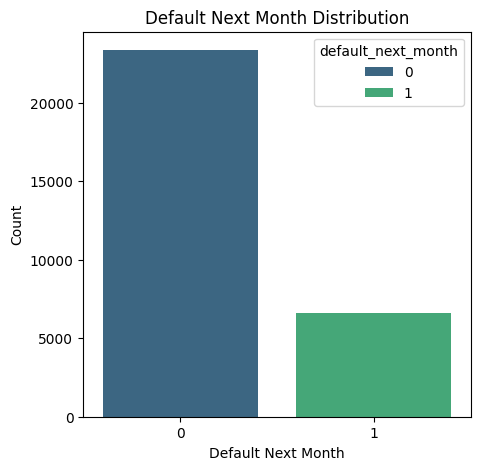

In [13]:
plt.figure(figsize=(5,5))
sns.countplot(x='default_next_month', hue='default_next_month', data=credit_df, palette='viridis')
plt.xlabel('Default Next Month')
plt.ylabel('Count')
plt.title('Default Next Month Distribution')
plt.show()

Default Rate

In [14]:
def_rate = (credit_df['default_next_month'].value_counts(normalize=True)*100).round(2)
def_rate

,proportion
default_next_month,
0,77.88
1,22.12


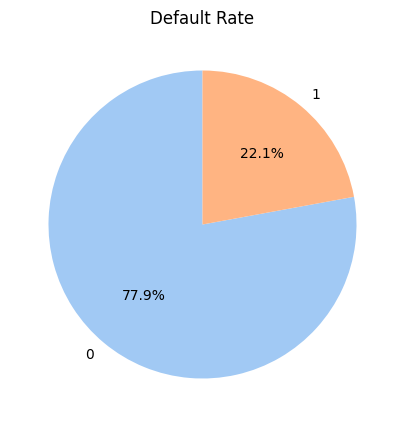

In [15]:
plt.figure(figsize=(5,5))
plt.pie(def_rate.values, labels=def_rate.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Default Rate')
plt.show()

Age vs default

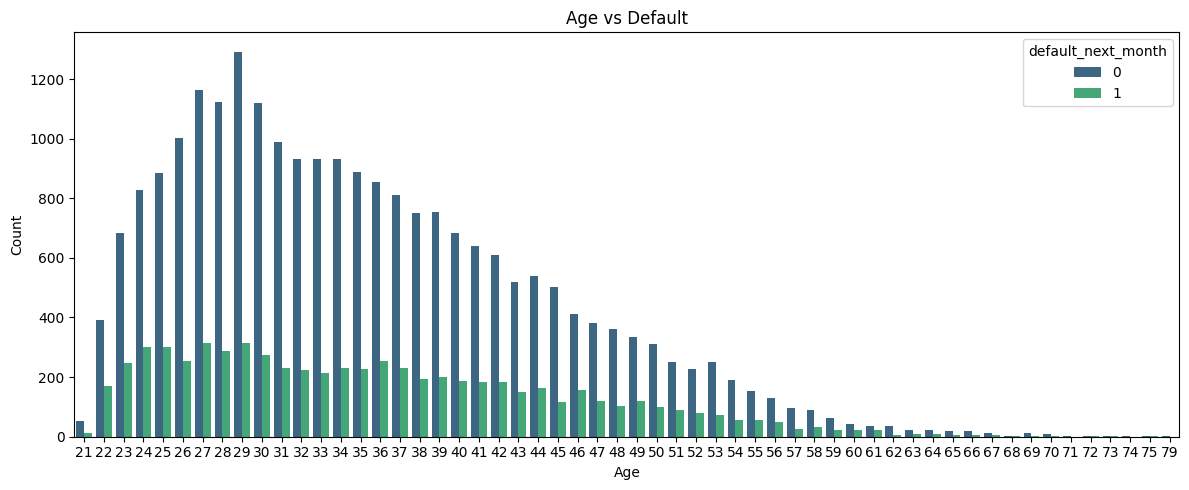

In [16]:
plt.figure(figsize=(12,5))
sns.countplot(x='age', hue='default_next_month', data=credit_df, palette='viridis')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age vs Default')
plt.tight_layout()
plt.show()

Credit Limit vs Default

/tmp/ipython-input-1102711930.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default_next_month', y='credit_limit', data=credit_df, palette='viridis')


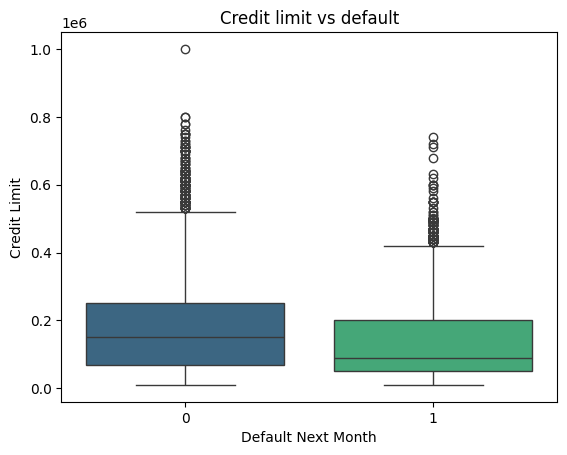

In [17]:
sns.boxplot(x='default_next_month', y='credit_limit', data=credit_df, palette='viridis')
plt.xlabel('Default Next Month')
plt.ylabel('Credit Limit')
plt.title("Credit limit vs default")
plt.show()

Correlation with Default

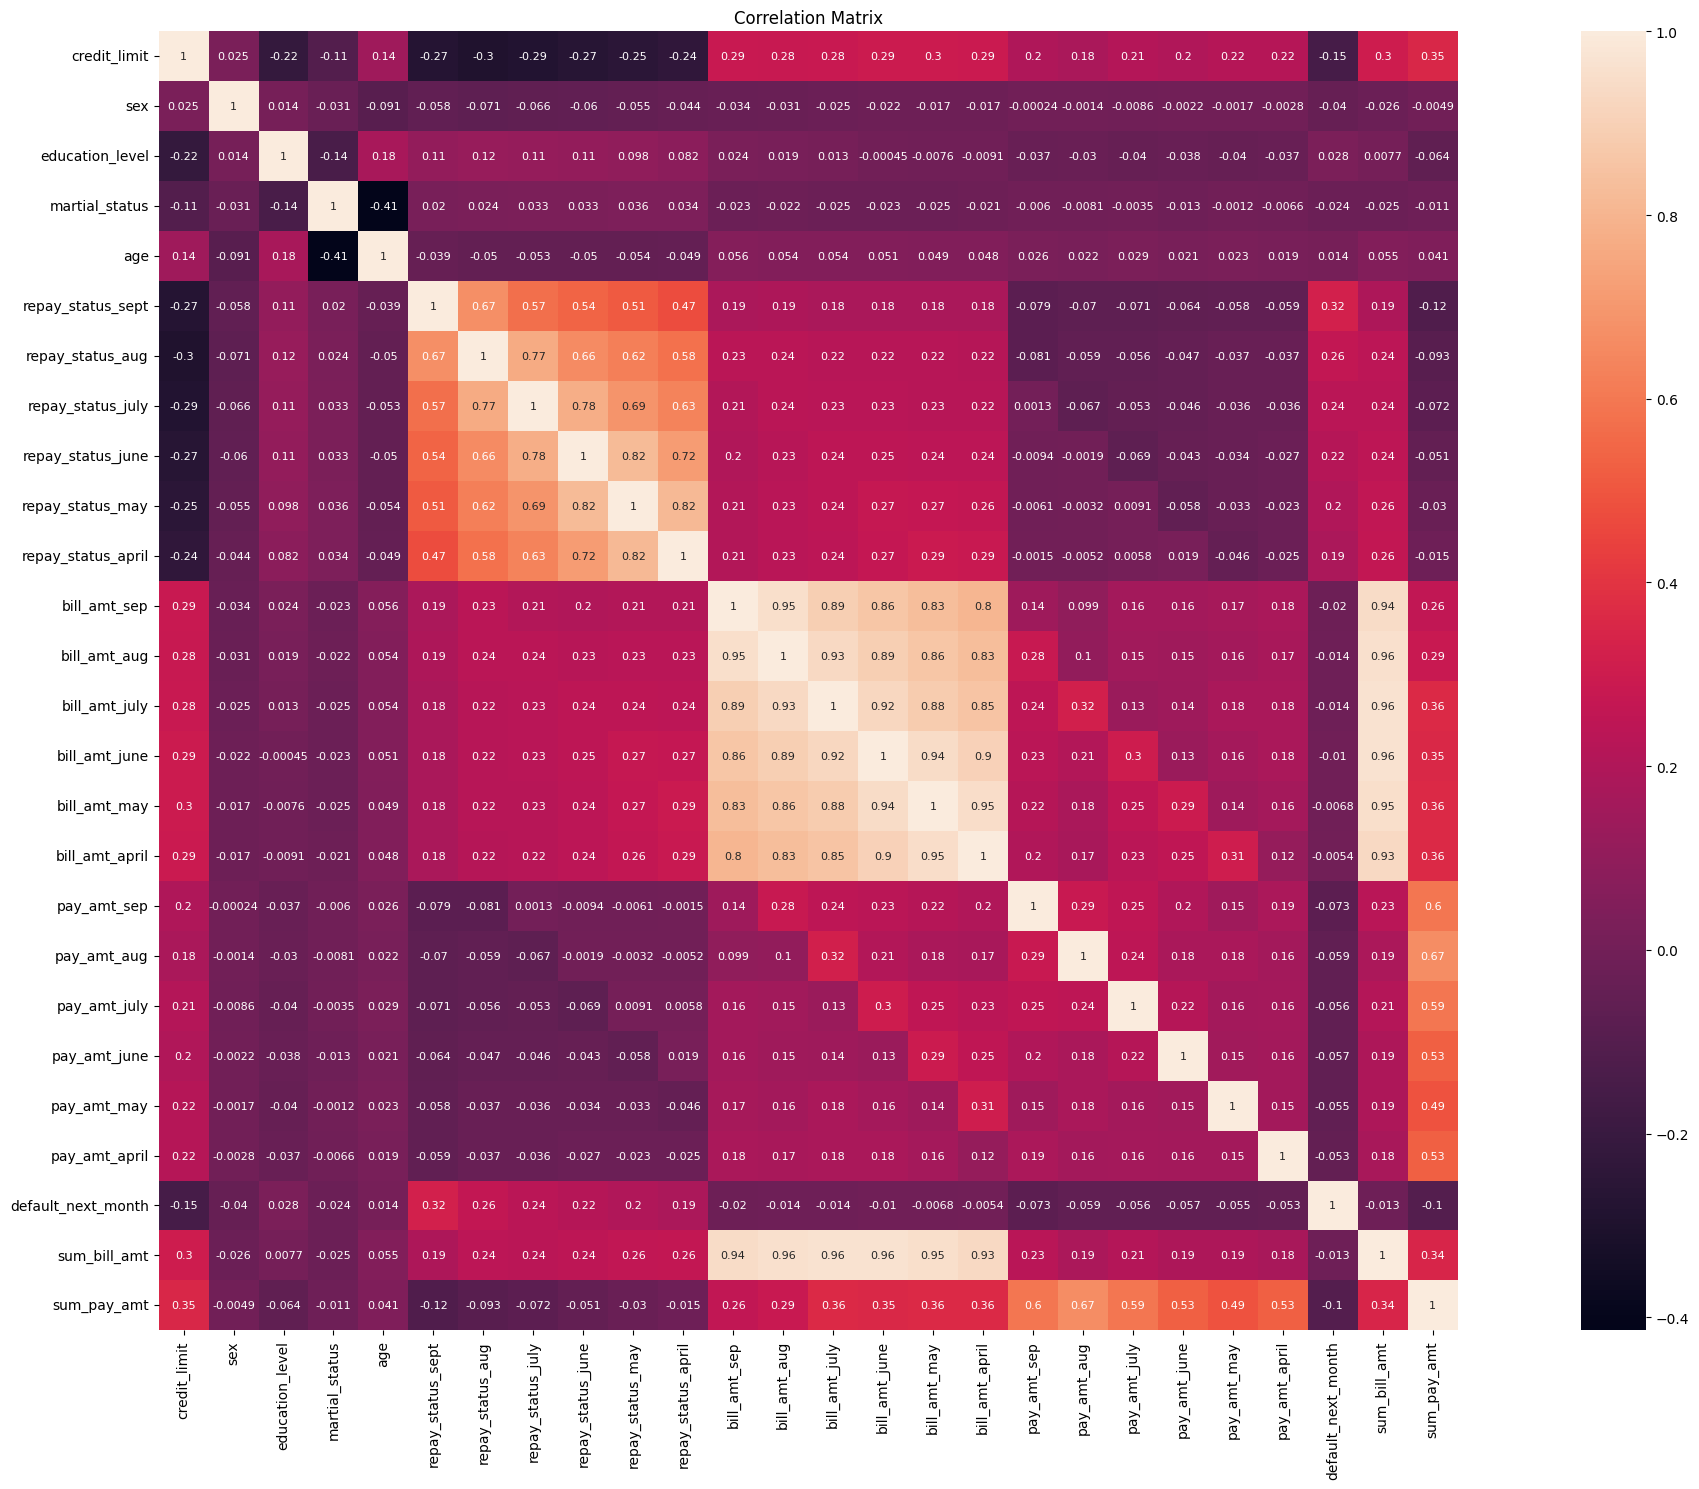

In [18]:
plt.figure(figsize=(25,15))
sns.heatmap(credit_df.corr(numeric_only=True), cbar=True, square=True, annot_kws={'size':8}, annot=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Identify Feature Types

In [19]:
cat_features = ['sex', 'education_level', 'martial_status', 'repay_status_sept', 'repay_status_aug', 'repay_status_july', 'repay_status_june', 'repay_status_may', 'repay_status_april']
num_features = credit_df.drop(cat_features + ['default_next_month'], axis=1).columns.tolist()

### Splitting the target & the features

In [20]:
X = credit_df.drop('default_next_month', axis=1)
y = credit_df['default_next_month']

### Removing the outliers of Credit Limit Using IQR Method

In [21]:
Q1 = credit_df['credit_limit'].quantile(0.25)
Q3 = credit_df['credit_limit'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

credit_df = credit_df[(credit_df['credit_limit'] >= lower_bound) & (credit_df['credit_limit'] <= upper_bound)]

print(f"New shape of the dataset after 'credit_limit' outlier removal: {credit_df.shape}")

New shape of the dataset after 'credit_limit' outlier removal: (29833, 26)


### Splitting the Data into Training & Testing

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### Building Preprocessing Pipelines

In [23]:
num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [24]:
cat_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [25]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

## Using Logistic Regression

### Full ML pipeline (Preprocessing + Model)

In [26]:
log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('log_reg', LogisticRegression())
])

In [27]:
log_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['credit_limit', 'age',
                                                   'bill_amt_sep',
                                                   'bill_amt_aug',
                                                   'bill_amt_july',
                                                   'bill_amt_june',
                                                   'bill_amt_may',
                                                   'bill_amt_april',
                                                   'pay_amt_sep', 'pay_amt_aug',
                                                   'pay_amt_july',
                                                   'pay_amt_june',
                                                   'pay_amt_may',
                                                   'pay_amt_april',
                                                   'sum_bill_amt',
                                                   'sum_pay_amt']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'education_level',
                                                   'martial_status',
                                                   'repay_status_sept',
                                                   'repay_status_aug',
                                                   'repay_status_july',
                                                   'repay_status_june',
                                                   'repay_status_may',
                                                   'repay_status_april'])])),
                ('log_reg', LogisticRegression())])

### Predictions on Testing Data

In [28]:
y_log_pred = log_pipeline.predict(X_test)

In [29]:
log_acc = accuracy_score(y_test, y_log_pred)
log_prec = precision_score(y_test, y_log_pred)
log_rec = recall_score(y_test, y_log_pred)
log_f1 = f1_score(y_test, y_log_pred)

print("Accuracy:", log_acc)
print("Precision:", log_prec)
print("Recall:", log_rec)
print("F1:", log_f1)

Accuracy: 0.8175
Precision: 0.6638418079096046
Recall: 0.3541823662396383
F1: 0.4619164619164619


### Apply custom threshold

In [30]:
y_log_pred_proba = log_pipeline.predict_proba(X_test)[:, 1]

In [31]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]
rows = []

for t in thresholds:
    y_log_pred_t = (y_log_pred_proba >= t).astype(int)
    rows.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_log_pred_t),
        "Precision": precision_score(y_test, y_log_pred_t),
        "Recall": recall_score(y_test, y_log_pred_t),
        "F1-Score": f1_score(y_test, y_log_pred_t)
    })

pd.DataFrame(rows)

,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.2,0.752500,0.454282,0.591560,0.513912
1,0.3,0.800333,0.556430,0.479277,0.514980
2,0.4,0.818000,0.639383,0.406179,0.496774
3,0.5,0.817500,0.663842,0.354182,0.461916
4,0.6,0.812500,0.679715,0.287867,0.404447


### Confusion Matrix

In [32]:
y_log_pred_03 = (y_log_pred_proba >= 0.3).astype(int)

In [33]:
log_cm = confusion_matrix(y_test, y_log_pred_03)
log_cm

array([[4166,  507],
       [ 691,  636]])

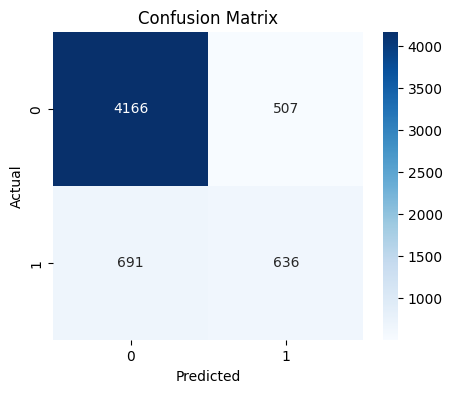

In [34]:
plt.figure(figsize=(5,4))
sns.heatmap(log_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [35]:
print(classification_report(y_test, y_log_pred_03))


              precision    recall  f1-score   support

           0       0.86      0.89      0.87      4673
           1       0.56      0.48      0.51      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.69      0.69      6000
weighted avg       0.79      0.80      0.79      6000



### ROC Curve

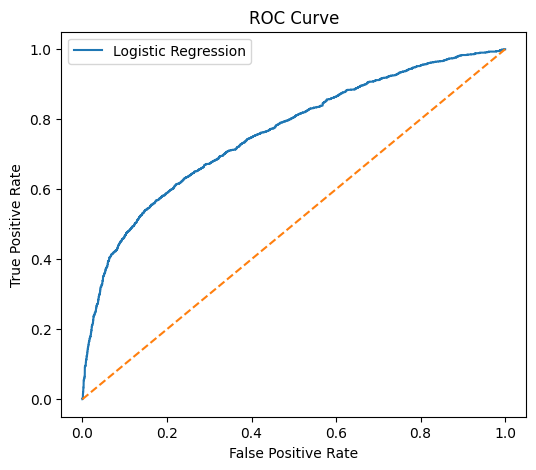

In [36]:
log_fpr, log_tpr, _ = roc_curve(y_test, y_log_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(log_fpr, log_tpr, label='Logistic Regression')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [37]:
roc_auc_score(y_test, y_log_pred_proba)

np.float64(0.7585168755526264)

## Using KNN

### Finding best k value & Full ML Pipeline

In [38]:
k_values = range(1, 21)
knn_f1_scores = []

for k in k_values:
    knn_distance = Pipeline([
        ('preprocess', preprocessor),
        ('knn', KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance'))
    ])
    knn_distance.fit(X_train, y_train)
    y_pred_dist = knn_distance.predict(X_test)
    knn_f1_scores.append(f1_score(y_test, y_pred_dist))

### Fitting the Training Data

In [40]:
best_k = k_values[knn_f1_scores.index(max(knn_f1_scores))]
print("Best k :", best_k)

Best k : 10


In [41]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', weights='distance'))
])

In [42]:
knn_pipeline.fit(X_train, y_train)
y_knn_pred = knn_pipeline.predict(X_test)

In [43]:
knn_acc = accuracy_score(y_test, y_knn_pred)
knn_prec = precision_score(y_test, y_knn_pred)
knn_rec = recall_score(y_test, y_knn_pred)
knn_f1 = f1_score(y_test, y_knn_pred)

print("Accuracy:", knn_acc)
print("Precision:", knn_prec)
print("Recall:", knn_rec)
print("F1:", knn_f1)

Accuracy: 0.8065
Precision: 0.6175637393767706
Recall: 0.3285606631499623
F1: 0.42892277422528285


### Apply custom threshold

In [44]:
y_knn_pred_proba = knn_pipeline.predict_proba(X_test)[:, 1]

In [45]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]
rows = []

for t in thresholds:
    y_knn_pred_t = (y_knn_pred_proba >= t).astype(int)
    rows.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_knn_pred_t),
        "Precision": precision_score(y_test, y_knn_pred_t),
        "Recall": recall_score(y_test, y_knn_pred_t),
        "F1-Score": f1_score(y_test, y_knn_pred_t)
    })

pd.DataFrame(rows)

,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.2,0.672833,0.364796,0.646571,0.466431
1,0.3,0.753500,0.450262,0.518463,0.481961
2,0.4,0.794333,0.545723,0.418237,0.473549
3,0.5,0.806500,0.617564,0.328561,0.428923
4,0.6,0.805500,0.661290,0.247174,0.359846


### Confusion Matrix

In [46]:
y_knn_pred_03 = (y_knn_pred_proba >= 0.3).astype(int)

In [47]:
knn_cm = confusion_matrix(y_test, y_knn_pred_03)
knn_cm

array([[3833,  840],
       [ 639,  688]])

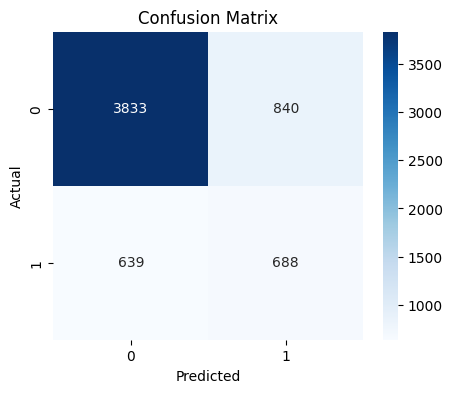

In [48]:
plt.figure(figsize=(5,4))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [49]:
print(classification_report(y_test, y_knn_pred_03))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      4673
           1       0.45      0.52      0.48      1327

    accuracy                           0.75      6000
   macro avg       0.65      0.67      0.66      6000
weighted avg       0.77      0.75      0.76      6000



### ROC Curve

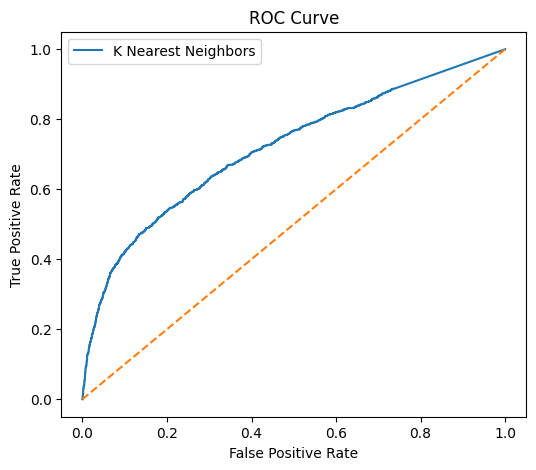

In [50]:
knn_fpr, knn_tpr, _ = roc_curve(y_test, y_knn_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(knn_fpr, knn_tpr, label='K Nearest Neighbors')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [51]:
roc_auc_score(y_test, y_knn_pred_proba)

np.float64(0.7181367541187643)

## Using Random Forest

### Full ML pipeline (Preprocessing + Model)

In [52]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('RandomForest', RandomForestClassifier())
])

In [53]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['credit_limit', 'age',
                                                   'bill_amt_sep',
                                                   'bill_amt_aug',
                                                   'bill_amt_july',
                                                   'bill_amt_june',
                                                   'bill_amt_may',
                                                   'bill_amt_april',
                                                   'pay_amt_sep', 'pay_amt_aug',
                                                   'pay_amt_july',
                                                   'pay_amt_june',
                                                   'pay_amt_may',
                                                   'pay_amt_april',
                                                   'sum_bill_amt',
                                                   'sum_pay_amt']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'education_level',
                                                   'martial_status',
                                                   'repay_status_sept',
                                                   'repay_status_aug',
                                                   'repay_status_july',
                                                   'repay_status_june',
                                                   'repay_status_may',
                                                   'repay_status_april'])])),
                ('RandomForest', RandomForestClassifier())])

### Predictions on Testing Data

In [54]:
y_rf_pred = rf_pipeline.predict(X_test)

In [55]:
rf_acc = accuracy_score(y_test, y_rf_pred)
rf_prec = precision_score(y_test, y_rf_pred)
rf_rec = recall_score(y_test, y_rf_pred)
rf_f1 = f1_score(y_test, y_rf_pred)

print("Accuracy:", rf_acc)
print("Precision:", rf_prec)
print("Recall:", rf_rec)
print("F1:", rf_f1)

Accuracy: 0.8135
Precision: 0.6361256544502618
Recall: 0.36623963828183875
F1: 0.4648493543758967


### Apply custom threshold

In [56]:
y_rf_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]

In [57]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]
rows = []

for t in thresholds:
    y_rf_pred_t = (y_rf_pred_proba >= t).astype(int)
    rows.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_rf_pred_t),
        "Precision": precision_score(y_test, y_rf_pred_t),
        "Recall": recall_score(y_test, y_rf_pred_t),
        "F1-Score": f1_score(y_test, y_rf_pred_t)
    })

pd.DataFrame(rows)

,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.2,0.682167,0.379668,0.689525,0.489698
1,0.3,0.774667,0.491782,0.563677,0.525281
2,0.4,0.800500,0.560748,0.452148,0.500626
3,0.5,0.813500,0.631980,0.375283,0.470922
4,0.6,0.810000,0.678095,0.268274,0.384449


### Confusion Matrix

In [58]:
y_rf_pred_03 = (y_rf_pred_proba >= 0.3).astype(int)

In [59]:
rf_cm = confusion_matrix(y_test, y_rf_pred_03)
rf_cm

array([[3900,  773],
       [ 579,  748]])

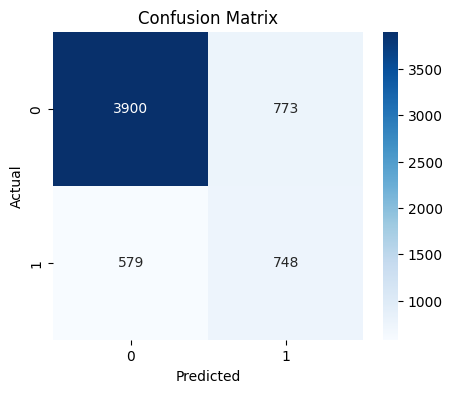

In [60]:
plt.figure(figsize=(5,4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [61]:
print(classification_report(y_test, y_rf_pred_03))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4673
           1       0.49      0.56      0.53      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.77      0.78      6000



### ROC Curve

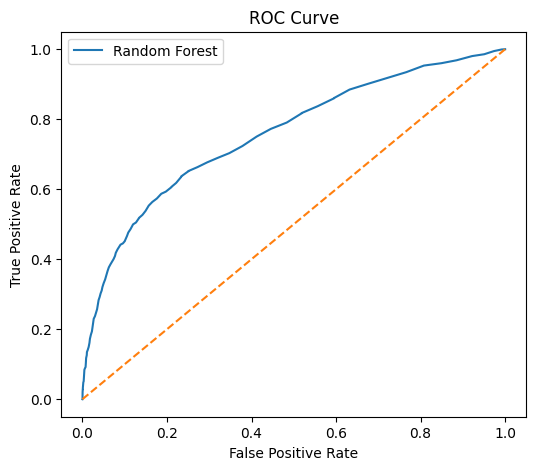

In [62]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_rf_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(rf_fpr, rf_tpr, label='Random Forest')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [63]:
roc_auc_score(y_test, y_rf_pred_proba)

np.float64(0.7565411684529977)

## Using Decision Tree Classifier

### Full ML pipeline (Preprocessing + Model)

In [64]:
max_depth_values = range(1, 16)
min_samples_leaf_values = [1, 5, 10, 20, 50, 100]
dec_tuning_results = []

for depth in max_depth_values:
    for min_leaf in min_samples_leaf_values:
        dec_pipeline_temp = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('dec_tree', DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=depth, min_samples_leaf=min_leaf))
        ])
        dec_pipeline_temp.fit(X_train, y_train)
        y_dec_pred_temp = dec_pipeline_temp.predict(X_test)
        f1 = f1_score(y_test, y_dec_pred_temp)
        dec_tuning_results.append({'max_depth': depth, 'min_samples_leaf': min_leaf, 'f1_score': f1})

dec_tuning_df = pd.DataFrame(dec_tuning_results)
best_dec_params = dec_tuning_df.loc[dec_tuning_df['f1_score'].idxmax()]

print("Best Decision Tree Parameters (based on F1-score):")
print(best_dec_params)

best_max_depth = int(best_dec_params['max_depth'])
best_min_samples_leaf = int(best_dec_params['min_samples_leaf'])

Best Decision Tree Parameters (based on F1-score):
max_depth           14.000000
min_samples_leaf    50.000000
f1_score             0.471529
Name: 82, dtype: float64


In [65]:
dec_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('dec_tree', DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=best_max_depth, min_samples_leaf=best_min_samples_leaf))
])

In [66]:
dec_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['credit_limit', 'age',
                                                   'bill_amt_sep',
                                                   'bill_amt_aug',
                                                   'bill_amt_july',
                                                   'bill_amt_june',
                                                   'bill_amt_may',
                                                   'bill_amt_april',
                                                   'pay_amt_sep', 'pay_amt_aug',
                                                   'pay_amt_july',
                                                   'pay_amt_june',
                                                   'pay_amt_may',
                                                   'pay_amt_april',
                                                   'sum_bill_amt',
                                                   'sum_pay_amt']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'education_level',
                                                   'martial_status',
                                                   'repay_status_sept',
                                                   'repay_status_aug',
                                                   'repay_status_july',
                                                   'repay_status_june',
                                                   'repay_status_may',
                                                   'repay_status_april'])])),
                ('dec_tree',
                 DecisionTreeClassifier(max_depth=14, min_samples_leaf=50,
                                        random_state=42))])

### Predictions on Testing Data

In [67]:
y_dec_pred = dec_pipeline.predict(X_test)

In [68]:
dec_acc = accuracy_score(y_test, y_dec_pred)
dec_prec = precision_score(y_test, y_dec_pred)
dec_rec = recall_score(y_test, y_dec_pred)
dec_f1 = f1_score(y_test, y_dec_pred)

print("Accuracy:", dec_acc)
print("Precision:", dec_prec)
print("Recall:", dec_rec)
print("F1:", dec_f1)

Accuracy: 0.8128333333333333
Precision: 0.6278195488721805
Recall: 0.3775433308214017
F1: 0.47152941176470586


### Apply custom threshold

In [69]:
y_dec_pred_proba = dec_pipeline.predict_proba(X_test)[:, 1]

In [70]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]
rows = []

for t in thresholds:
    y_dec_pred_t = (y_dec_pred_proba >= t).astype(int)
    rows.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_dec_pred_t),
        "Precision": precision_score(y_test, y_dec_pred_t),
        "Recall": recall_score(y_test, y_dec_pred_t),
        "F1-Score": f1_score(y_test, y_dec_pred_t)
    })

pd.DataFrame(rows)

,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.2,0.698667,0.391422,0.653353,0.489554
1,0.3,0.771333,0.484889,0.544084,0.512784
2,0.4,0.795833,0.545946,0.456669,0.497333
3,0.5,0.812833,0.627820,0.377543,0.471529
4,0.6,0.808000,0.685775,0.243406,0.359288


### Confusion Matrix

In [71]:
y_dec_pred_03 = (y_dec_pred_proba >= 0.3).astype(int)

In [72]:
dec_cm = confusion_matrix(y_test, y_dec_pred_03)
dec_cm

array([[3906,  767],
       [ 605,  722]])

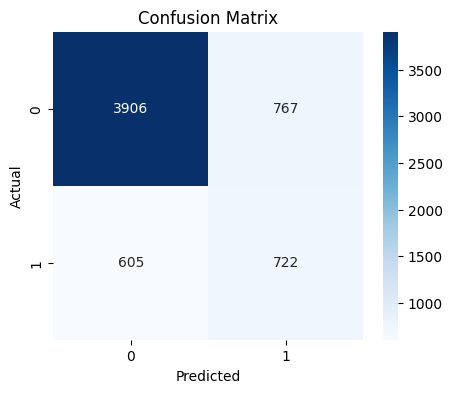

In [73]:
plt.figure(figsize=(5,4))
sns.heatmap(dec_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [74]:
print(classification_report(y_test, y_dec_pred_03))

              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.48      0.54      0.51      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.69      0.68      6000
weighted avg       0.78      0.77      0.78      6000



### ROC Curve

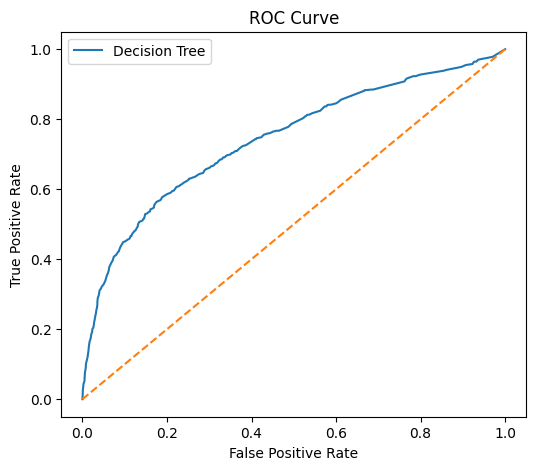

In [75]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_dec_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(rf_fpr, rf_tpr, label='Decision Tree')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [76]:
roc_auc_score(y_test, y_dec_pred_proba)

np.float64(0.7418750728704767)

## Using SVC

### Full ML pipeline (Preprocessing + Model)

In [89]:
svc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svc', SVC(kernel='linear', random_state=42))
])

In [90]:
svc_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['credit_limit', 'age',
                                                   'bill_amt_sep',
                                                   'bill_amt_aug',
                                                   'bill_amt_july',
                                                   'bill_amt_june',
                                                   'bill_amt_may',
                                                   'bill_amt_april',
                                                   'pay_amt_sep', 'pay_amt_aug',
                                                   'pay_amt_july',
                                                   'pay_amt_june',
                                                   'pay_amt_may',
                                                   'pay_amt_april',
                                                   'sum_bill_amt',
                                                   'sum_pay_amt']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'education_level',
                                                   'martial_status',
                                                   'repay_status_sept',
                                                   'repay_status_aug',
                                                   'repay_status_july',
                                                   'repay_status_june',
                                                   'repay_status_may',
                                                   'repay_status_april'])])),
                ('svc', SVC(kernel='linear', random_state=42))])

### Predictions on Testing Data

In [91]:
y_svc_pred = svc_pipeline.predict(X_test)

In [95]:
svc_acc = accuracy_score(y_test, y_svc_pred)
svc_prec = precision_score(y_test, y_svc_pred)
svc_rec = recall_score(y_test, y_svc_pred)
svc_f1 = f1_score(y_test, y_svc_pred)

print("Accuracy:", svc_acc)
print("Precision:", svc_prec)
print("Recall:", svc_rec)
print("F1:", svc_f1)

Accuracy: 0.8188333333333333
Precision: 0.6910828025477707
Recall: 0.32705350414468726
F1: 0.4439897698209719


### Confusion Matrix

In [101]:
svc_cm = confusion_matrix(y_test, y_svc_pred)
svc_cm

array([[4479,  194],
       [ 893,  434]])

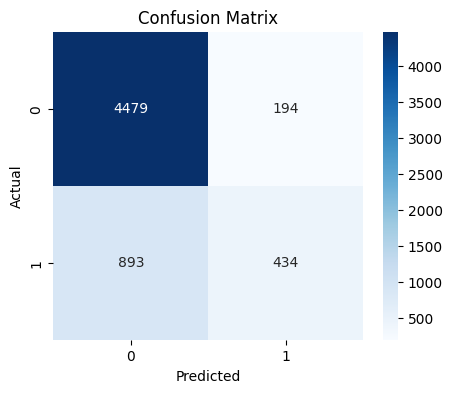

In [102]:
plt.figure(figsize=(5,4))
sns.heatmap(svc_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [103]:
print(classification_report(y_test, y_svc_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4673
           1       0.69      0.33      0.44      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000



## Model Comparisions

In [100]:
model_names = ['Logistic Regression', 'K-Nearest Neighbors', 'Random Forest', 'Decision Tree', 'Support Vector Classifier']

metrics = {
    'Accuracy': [
        accuracy_score(y_test, y_log_pred_03),
        accuracy_score(y_test, y_knn_pred_03),
        accuracy_score(y_test, y_rf_pred_03),
        accuracy_score(y_test, y_dec_pred_03),
        svc_acc
    ],
    'Precision': [
        precision_score(y_test, y_log_pred_03),
        precision_score(y_test, y_knn_pred_03),
        precision_score(y_test, y_rf_pred_03),
        precision_score(y_test, y_dec_pred_03),
        svc_prec
    ],
    'Recall': [
        recall_score(y_test, y_log_pred_03),
        recall_score(y_test, y_knn_pred_03),
        recall_score(y_test, y_rf_pred_03),
        recall_score(y_test, y_dec_pred_03),
        svc_rec
    ],
    'F1-Score': [
        f1_score(y_test, y_log_pred_03),
        f1_score(y_test, y_knn_pred_03),
        f1_score(y_test, y_rf_pred_03),
        f1_score(y_test, y_dec_pred_03),
        svc_f1
    ]
}

comparison_df = pd.DataFrame(metrics, index=model_names)
print("\nModel Performance Comparison (using 0.3 threshold for probability-based models, raw for SVC):\n")
comparison_df


Model Performance Comparison (using 0.3 threshold for probability-based models, raw for SVC):



,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.800333,0.556430,0.479277,0.514980
K-Nearest Neighbors,0.753500,0.450262,0.518463,0.481961
Random Forest,0.774667,0.491782,0.563677,0.525281
Decision Tree,0.771333,0.484889,0.544084,0.512784
Support Vector Classifier,0.818833,0.691083,0.327054,0.443990


In [99]:
best_model_f1 = comparison_df['F1-Score'].idxmax()
print(f"\nBest performing model based on F1-score: {best_model_f1}")


Best performing model based on F1-score: Random Forest


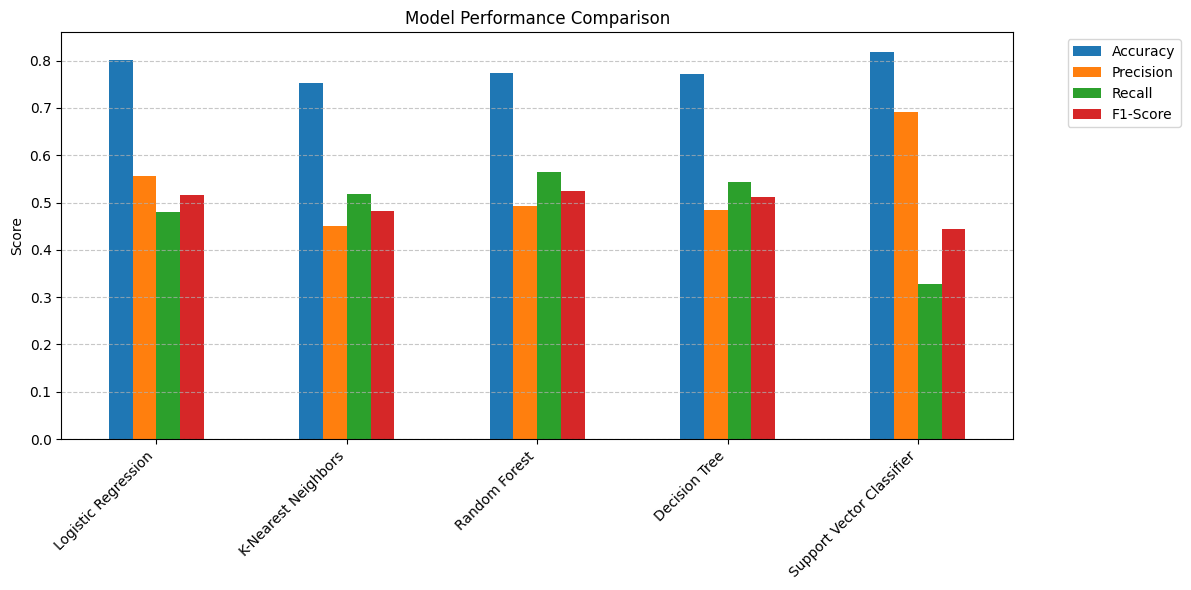

In [110]:
comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

We are comparing based on f1-score (recall or precision) instead of accuracy because this is imbalanced dataset, so Random Forest is the Best Model for prediction.

### Saving the Pipeline

In [112]:
joblib.dump(rf_pipeline, "credit_card_default_pipeline.pkl")

['credit_card_default_pipeline.pkl']

### Loading for New Predictions

In [118]:
def predict_default(client_attributes: dict):
    input_df = pd.DataFrame([client_attributes])

    prob = rf_pipeline.predict_proba(input_df)[0, 1]
    pred_custom = int(prob >= 0.3)

    print(f"Probability of Default: {prob:.4f}")
    print("Prediction:", pred_custom)


    return pred_custom

In [119]:
sample_client_attributes = {
    'credit_limit': 120000.0,
    'sex': 2,
    'education_level': 2,
    'martial_status': 2,
    'age': 26,
    'repay_status_sept': -1,
    'repay_status_aug': 2,
    'repay_status_july': 0,
    'repay_status_june': 0,
    'repay_status_may': 0,
    'repay_status_april': 2,
    'bill_amt_sep': 2682.0,
    'bill_amt_aug': 1725.0,
    'bill_amt_july': 2682.0,
    'bill_amt_june': 3272.0,
    'bill_amt_may': 3455.0,
    'bill_amt_april': 3261.0,
    'pay_amt_sep': 0.0,
    'pay_amt_aug': 1000.0,
    'pay_amt_july': 1000.0,
    'pay_amt_june': 1000.0,
    'pay_amt_may': 0.0,
    'pay_amt_april': 2000.0,
}

sample_client_attributes['sum_bill_amt'] = sum(sample_client_attributes[col] for col in sample_client_attributes if col.startswith('bill_amt_'))
sample_client_attributes['sum_pay_amt'] = sum(sample_client_attributes[col] for col in sample_client_attributes if col.startswith('pay_amt_'))

prediction = predict_default(sample_client_attributes)

if prediction == 1:
    print("Prediction: The client is likely to default next month.")
else:
    print("Prediction: The client is not likely to default next month.")

Probability of Default: 0.3400
Prediction: 1
Prediction: The client is likely to default next month.
